<a href="https://colab.research.google.com/github/palash116/FirstCode2025/blob/main/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Font family setup

In [89]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12

# Two activation functions

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Two most important activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

In [91]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=100, mode='batch'):
        self.lr = lr
        self.epochs = epochs
        self.mode = mode
        self.w = None
        self.b = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0

        # Convert y to a NumPy array for consistent integer indexing
        y = y.to_numpy() if isinstance(y, pd.Series) else y

        for epoch in range(self.epochs):
            if self.mode == 'batch':
                z = X.dot(self.w) + self.b
                pred = self.sigmoid(z)
                self.w -= self.lr * X.T.dot(pred - y) / n
                self.b -= self.lr * (pred - y).mean()
            else:
                for i in range(n):
                    z = X[i].dot(self.w) + self.b
                    pred = self.sigmoid(z)
                    self.w -= self.lr * (pred - y[i]) * X[i]
                    self.b -= self.lr * (pred - y[i])

    def predict(self, X):
        return (self.sigmoid(X.dot(self.w) + self.b) >= 0.5).astype(int)

print("Perceptron class created!")

Perceptron class created!


# Load and explore dataset

In [93]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/datasets/creditcard.csv")

In [95]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [96]:
print("\n dataset shape:", df.shape)


 dataset shape: (284807, 31)


In [97]:
print("\nTarget variable distribution:")
print(df['Class'].value_counts())


Target variable distribution:
Class
0    284315
1       492
Name: count, dtype: int64


# Prepare data

In [98]:
print("\nCheck for missing values:")
print(df.isnull().sum())


Check for missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## Loaded packages

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [100]:
X = df.drop('Class', axis=1)  # Everything except Outcome
y = df['Class']                # Only Outcome

## Handle imbalance

In [101]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_balanced, y_balanced = rus.fit_resample(X, y)

In [102]:
print(f"Total samples: {len(X_balanced)}")
print(f"0: {sum(y_balanced)}, Others: {len(y_balanced) - sum(y_balanced)}")

Total samples: 984
0: 492, Others: 492


## Train-Test Split

In [104]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

## Standardize

In [105]:
# Standardize (important!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\nData ready!")


Data ready!


# Train two models

## Batch Gradient Descent

In [106]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Train with Batch GD
print("="*50)
print("Training with BATCH Gradient Descent")
print("="*50)

model_batch = Perceptron(lr=0.1, epochs=200, mode='batch')
model_batch.fit(X_train, y_train)

y_pred_batch = model_batch.predict(X_test)
acc_batch = accuracy_score(y_test, y_pred_batch)
prec_batch = precision_score(y_test, y_pred_batch)
rec_batch = recall_score(y_test, y_pred_batch)
f1_batch = f1_score(y_test, y_pred_batch)

print(f"\nTest Accuracy:  {acc_batch*100:.2f}%")
print(f"Precision:      {prec_batch*100:.2f}%")
print(f"Recall:         {rec_batch*100:.2f}%")
print(f"F1-Score:       {f1_batch*100:.2f}%")
print(f"\nCorrect: {sum(y_pred_batch == y_test)}/{len(y_test)}")

Training with BATCH Gradient Descent

Test Accuracy:  90.86%
Precision:      100.00%
Recall:         81.63%
F1-Score:       89.89%

Correct: 179/197


## Stochastic Gradient Descent

In [107]:
print("="*50)
print("Training with STOCHASTIC Gradient Descent")
print("="*50)

model_sgd = Perceptron(lr=0.01, epochs=200, mode='stochastic')
model_sgd.fit(X_train, y_train)

y_pred_sgd = model_sgd.predict(X_test)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
prec_sgd = precision_score(y_test, y_pred_sgd)
rec_sgd = recall_score(y_test, y_pred_sgd)
f1_sgd = f1_score(y_test, y_pred_sgd)

print(f"\nTest Accuracy:  {acc_sgd*100:.2f}%")
print(f"Precision:      {prec_sgd*100:.2f}%")
print(f"Recall:         {rec_sgd*100:.2f}%")
print(f"F1-Score:       {f1_sgd*100:.2f}%")
print(f"\nCorrect: {sum(y_pred_sgd == y_test)}/{len(y_test)}")

Training with STOCHASTIC Gradient Descent

Test Accuracy:  93.40%
Precision:      95.70%
Recall:         90.82%
F1-Score:       93.19%

Correct: 184/197


# Compare:

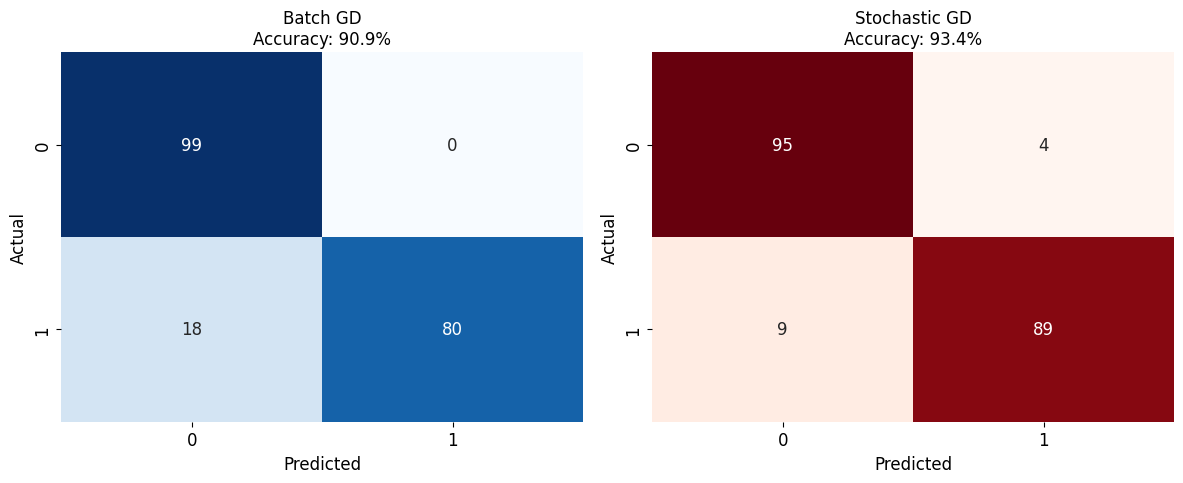


COMPARISON: Batch GD vs Stochastic GD
Metric               Batch GD             Stochastic GD       
----------------------------------------------------------------------
Accuracy                          90.86%              93.40%
Precision                        100.00%              95.70%
Recall                            81.63%              90.82%
F1-Score                          89.89%              93.19%
Training complete!


In [108]:
# Compare Results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix - Batch
cm_batch = confusion_matrix(y_test, y_pred_batch)
sns.heatmap(cm_batch, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Batch GD\nAccuracy: {acc_batch*100:.1f}%', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix - Stochastic
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title(f'Stochastic GD\nAccuracy: {acc_sgd*100:.1f}%', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print comparison table
print("\n" + "="*70)
print("COMPARISON: Batch GD vs Stochastic GD")
print("="*70)
print(f"{'Metric':<20} {'Batch GD':<20} {'Stochastic GD':<20}")
print("-"*70)
print(f"{'Accuracy':<20} {acc_batch*100:>18.2f}% {acc_sgd*100:>18.2f}%")
print(f"{'Precision':<20} {prec_batch*100:>18.2f}% {prec_sgd*100:>18.2f}%")
print(f"{'Recall':<20} {rec_batch*100:>18.2f}% {rec_sgd*100:>18.2f}%")
print(f"{'F1-Score':<20} {f1_batch*100:>18.2f}% {f1_sgd*100:>18.2f}%")
print("="*70)
print("Training complete!")
print("="*70)